# Returns & volatility — distribuição de risco

Antes de prever, precisas saber **quão errado o teu modelo vai estar**.

- Distribuição dos log-returns: gaussiana? fat tails?
- Volatility clustering (efeito GARCH)?
- Drawdowns: qual o pior cenário típico?
- Risco varia com tier de preço / liquidez?

Isto informa: (a) escolha de loss function (MSE vs quantile loss), (b) intervalos de previsão, (c) que items são modeláveis e quais são casino.

In [10]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf

PARQUET = "../data/items.parquet"

In [11]:
import sys; sys.path.insert(0, ".")
from _helpers import get_daily, list_top_items

## 1. Sample de items + cálculo de log-returns

In [ ]:
top = list_top_items(n=50, min_history_days=365 * 3 * 24)
print(f"Universo: {top.height} items")

def returns_stats(name):
    df = get_daily(name).filter(pl.col("price") > 0)
    if df.height < 100:
        return None
    p = df["price"].to_numpy()
    r = np.diff(np.log(p))
    return {
        "name": name,
        "n": len(r),
        "mean_bps": float(r.mean() * 1e4),
        "vol_daily_%": float(r.std() * 100),
        "vol_ann_%": float(r.std() * np.sqrt(365) * 100),
        "skew": float(stats.skew(r)),
        "kurt": float(stats.kurtosis(r)),
        "max_dd_%": float((np.minimum.accumulate(p/np.maximum.accumulate(p)) - 1).min() * 100),
    }

rows = [returns_stats(n) for n in top["name"].to_list()]
stats_df = pl.DataFrame([r for r in rows if r])
print(stats_df.sort("vol_ann_%", descending=True).head(15))

## 2. Distribuição dos returns — gaussiana?

In [ ]:
print("Estatísticas agregadas dos returns diários:")
print(stats_df.select(["mean_bps", "vol_daily_%", "skew", "kurt", "max_dd_%"]).describe())
print("\nNota: kurtosis (excess) > 0 → fat tails. Gauss = 0. Equities ~5-10. Crypto ~20+.")

Estatísticas agregadas dos returns diários:
shape: (9, 6)
┌────────────┬───────────┬─────────────┬───────────┬────────────┬────────────┐
│ statistic  ┆ mean_bps  ┆ vol_daily_% ┆ skew      ┆ kurt       ┆ max_dd_%   │
│ ---        ┆ ---       ┆ ---         ┆ ---       ┆ ---        ┆ ---        │
│ str        ┆ f64       ┆ f64         ┆ f64       ┆ f64        ┆ f64        │
╞════════════╪═══════════╪═════════════╪═══════════╪════════════╪════════════╡
│ count      ┆ 50.0      ┆ 50.0        ┆ 50.0      ┆ 50.0       ┆ 50.0       │
│ null_count ┆ 0.0       ┆ 0.0         ┆ 0.0       ┆ 0.0        ┆ 0.0        │
│ mean       ┆ -0.036717 ┆ 9.453074    ┆ 1.133267  ┆ 168.827969 ┆ -94.859911 │
│ std        ┆ 3.979951  ┆ 4.888415    ┆ 2.463303  ┆ 200.270933 ┆ 5.123553   │
│ min        ┆ -7.72292  ┆ 4.747754    ┆ -4.771248 ┆ 8.034819   ┆ -99.68675  │
│ 25%        ┆ -3.505969 ┆ 6.095704    ┆ -0.142782 ┆ 45.257166  ┆ -98.478682 │
│ 50%        ┆ 0.347634  ┆ 7.734304    ┆ 0.217801  ┆ 113.640591 ┆ -96.724

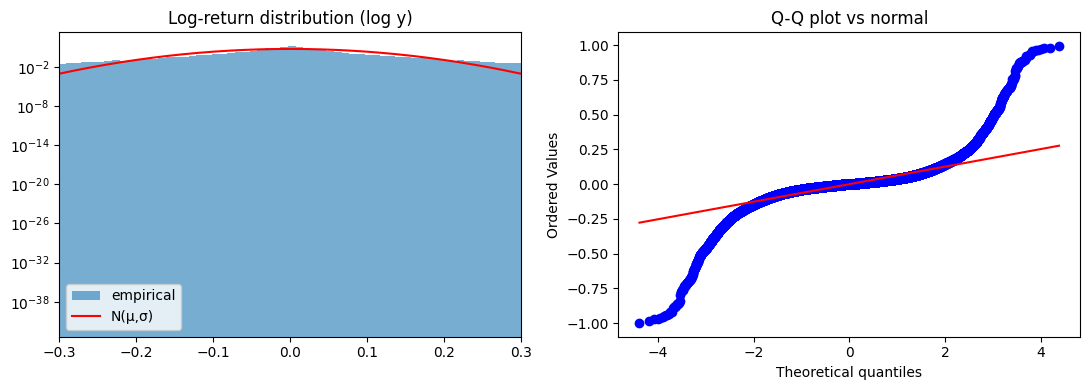

In [ ]:
# QQ-plot agregando returns de vários items para ver fat tails
all_r = []
for name in top["name"].to_list()[:30]:
    df = get_daily(name).filter(pl.col("price") > 0)
    if df.height < 200: continue
    r = np.diff(np.log(df["price"].to_numpy()))
    r = r[np.abs(r) < 1]  # corta outliers brutos
    all_r.append(r)
flat = np.concatenate(all_r)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(flat, bins=200, density=True, alpha=0.6, label="empirical")
xs = np.linspace(flat.min(), flat.max(), 400)
axes[0].plot(xs, stats.norm.pdf(xs, flat.mean(), flat.std()), "r-", label="N(μ,σ)")
axes[0].set_yscale("log"); axes[0].set_xlim(-0.3, 0.3)
axes[0].set_title("Log-return distribution (log y)")
axes[0].legend()
stats.probplot(flat, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs normal")
plt.tight_layout(); plt.show()

## 3. Volatility clustering (efeito ARCH)

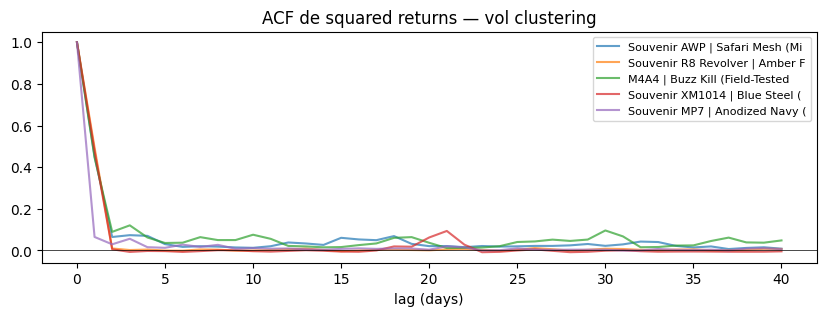

Se persiste >0 por muitos lags → modelo GARCH adiciona valor.


In [ ]:
# ACF dos squared returns: se decai lentamente → vol clustering
fig, ax = plt.subplots(figsize=(10, 3))
for name in top["name"].to_list()[:5]:
    df = get_daily(name).filter(pl.col("price") > 0)
    if df.height < 500: continue
    r = np.diff(np.log(df["price"].to_numpy()))
    a = acf(r**2, nlags=40)
    ax.plot(a, label=name[:30], alpha=0.7)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("ACF de squared returns — vol clustering")
ax.set_xlabel("lag (days)")
ax.legend(fontsize=8)
plt.show()
print("Se persiste >0 por muitos lags → modelo GARCH adiciona valor.")

## 4. Rolling 30d volatility

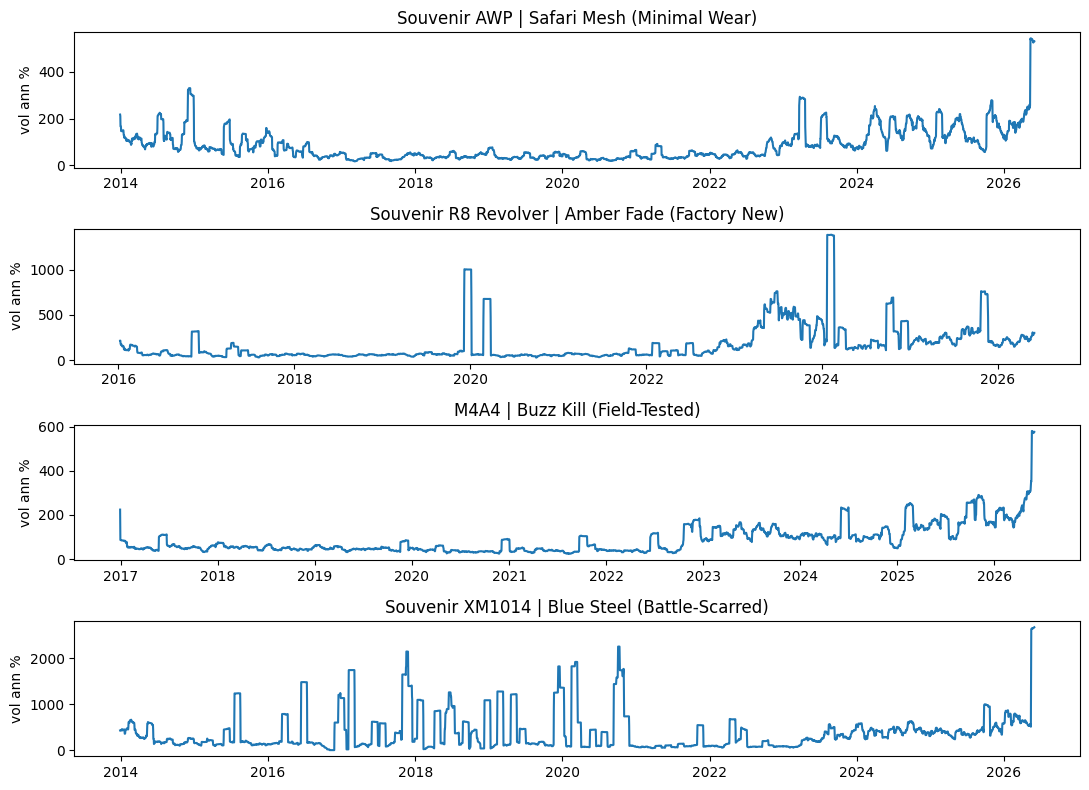

In [ ]:
SAMPLES = top["name"].head(4).to_list()
fig, axes = plt.subplots(len(SAMPLES), 1, figsize=(11, 8), sharex=False)
for ax, name in zip(axes, SAMPLES):
    df = get_daily(name).filter(pl.col("price") > 0)
    p = df["price"].to_numpy()
    r = np.diff(np.log(p))
    vol30 = pl.Series(r).rolling_std(30).to_numpy() * np.sqrt(365) * 100
    ax.plot(df["date"][1:], vol30)
    ax.set_title(name[:50])
    ax.set_ylabel("vol ann %")
plt.tight_layout(); plt.show()

## 5. Drawdowns

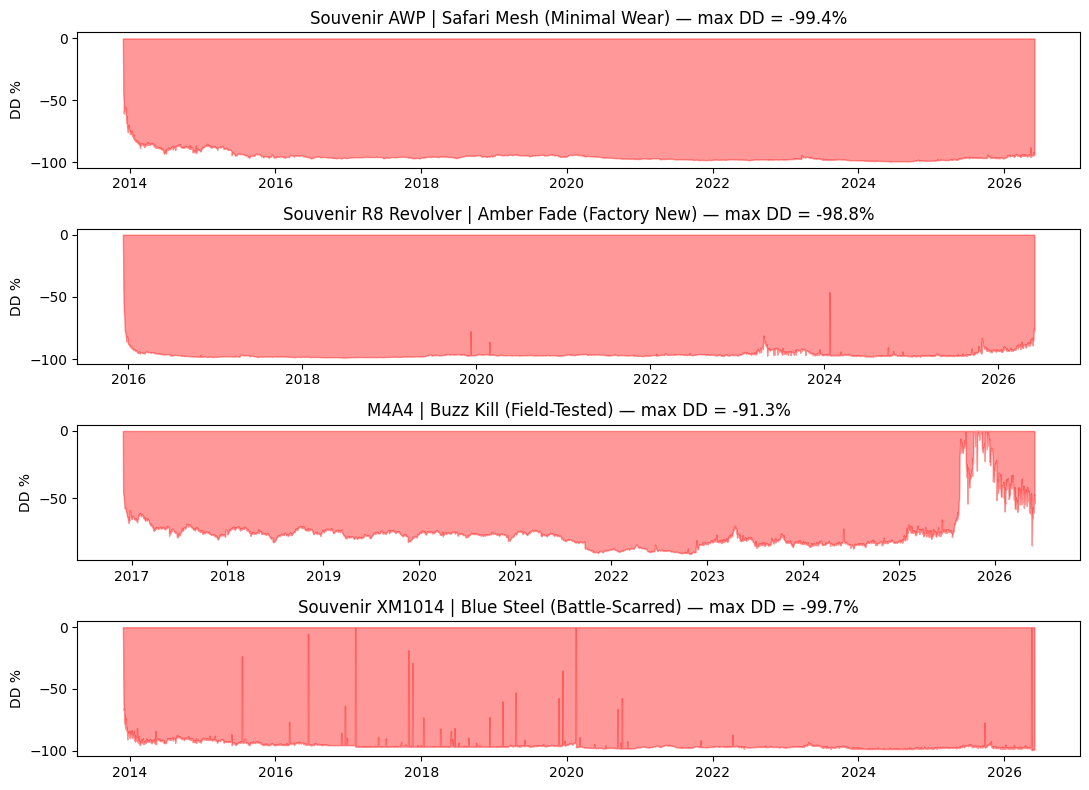

In [ ]:
def dd_series(p):
    roll_max = np.maximum.accumulate(p)
    return p / roll_max - 1

fig, axes = plt.subplots(len(SAMPLES), 1, figsize=(11, 8), sharex=False)
for ax, name in zip(axes, SAMPLES):
    df = get_daily(name).filter(pl.col("price") > 0)
    dd = dd_series(df["price"].to_numpy()) * 100
    ax.fill_between(df["date"], dd, 0, color="red", alpha=0.4)
    ax.set_title(f"{name[:50]} — max DD = {dd.min():.1f}%")
    ax.set_ylabel("DD %")
plt.tight_layout(); plt.show()

## 6. Vol vs tier de preço

In [ ]:
joined = (
    stats_df.join(top.select(["name", "steam", "steam_vol"]), on="name", how="inner")
            .with_columns(
                pl.when(pl.col("steam") < 10).then(pl.lit("<$10"))
                  .when(pl.col("steam") < 100).then(pl.lit("$10-100"))
                  .when(pl.col("steam") < 500).then(pl.lit("$100-500"))
                  .otherwise(pl.lit(">$500")).alias("tier")
            )
)

print(
    joined.group_by("tier").agg([
        pl.len().alias("n"),
        pl.col("vol_ann_%").median().round(1).alias("vol_med"),
        pl.col("kurt").median().round(1).alias("kurt_med"),
        pl.col("max_dd_%").median().round(1).alias("dd_med"),
    ]).sort("vol_med", descending=True)
)

shape: (2, 5)
┌──────────┬─────┬─────────┬──────────┬────────┐
│ tier     ┆ n   ┆ vol_med ┆ kurt_med ┆ dd_med │
│ ---      ┆ --- ┆ ---     ┆ ---      ┆ ---    │
│ str      ┆ u32 ┆ f64     ┆ f64      ┆ f64    │
╞══════════╪═════╪═════════╪══════════╪════════╡
│ >$500    ┆ 2   ┆ 185.8   ┆ 85.6     ┆ -99.1  │
│ $100-500 ┆ 48  ┆ 147.8   ┆ 109.8    ┆ -96.6  │
└──────────┴─────┴─────────┴──────────┴────────┘


## Conclusões a confirmar
- Kurtosis típica > 3 → modelo deve assumir t-Student ou usar quantile loss
- Vol clustering presente → considerar GARCH(1,1) ou features de rolling vol
- Items <$10 com vol absurda + max DD enorme → tirar do universo modelável